In [6]:

from tabulate import tabulate

# Define the data
data = [
    ["SVM model using TF-IDF vectors and Unigram+Bigram", ""],
    ["Type of Smoothing Used?", "SMOTE - OVER SAMPLING"],
    ["Config of model trained?", "YES"],
    ["Train Time = ?", "21.7638 seconds"],
    ["Training Data Check", "YES"],
    ["Confusion Matrix Built?", "YES"],
    ["F1 Score for Positive = ?", "1.00"],
    ["F1 Score for Negative = ?", "0.99"],
    ["AUC plotted?", "NO"],
    ["AUC = ?", ""],
    ["Accuracy computed?", "YES"],
    ["Accuracy = ?", "0.99"],
    ["Feature Engg", "review_length and polarity"],
    ["Feature Weightages Added?", "YES"],
    ["2 Features with the Highest Weights?", "(trivia, 1.834247),(customer, 1.749706)"],
    ["Cross Validation", "YES"],
    ["Type of Cross Validation performed?", "K-FOLD"],
    ["Findings of Cross Validation?", "The mean cross-validation score is 94.72%, indicating strong overall performance"],
    ["Next Steps", "Testing Data Check"],
    ["Testing Data Check", "YES"],
    ["Confusion Matrix Built?", "YES"],
    ["F1 Score for Positive = ?", "0.90"],
    ["F1 Score for Negative = ?", "0.72"],
    ["AUC plotted?", "NO"],
    ["AUC = ?", ""],
    ["Accuracy computed?", "YES"],
    ["Accuracy = ?", "0.80"],
    ["Next Steps", "YES"],
    ["List out 2-3 possible next steps for Naive Bayes Models", "1. Hyperparameter Tuning: Use GridSearchCV or RandomizedSearchCV to optimize model hyperparameters.\n2. Use Deep Learning: If performance plateaus, moving to deep learning techniques like BERT for text classification could yield significant improvements."],
]

# Display table
print(tabulate(data, headers=["Category", "Details"], tablefmt="grid"))



+---------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------+
| Category                                                | Details                                                                                                                                                   |
+=========================================================+===========================================================================================================================================================+
| SVM model using TF-IDF vectors and Unigram+Bigram       |                                                                                                                                                           |
+---------------------------------------------------------+-----------------------------------------------------------------------------

####**Import Required Libraries**

In [ ]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

import re
import string

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score


from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    f1_score,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay,
)

####**The Dataset**

In [ ]:
data = pd.read_csv('/content/yelp_review.csv') #20,000 rows and 9 columns

In [ ]:
df = data.sample(n=5000, random_state=42)

In [ ]:
df.shape

(5000, 9)

In [ ]:
# Label Mapping
def map_label(star):
    if star >= 4:
        return "Positive"
    elif star == 3:
        return "Neutral"
    else:
        return "Negative"

df['label'] = df['stars'].apply(map_label)

In [ ]:
df.value_counts('label')

,count
label,
Positive,3515
Negative,930
Neutral,555


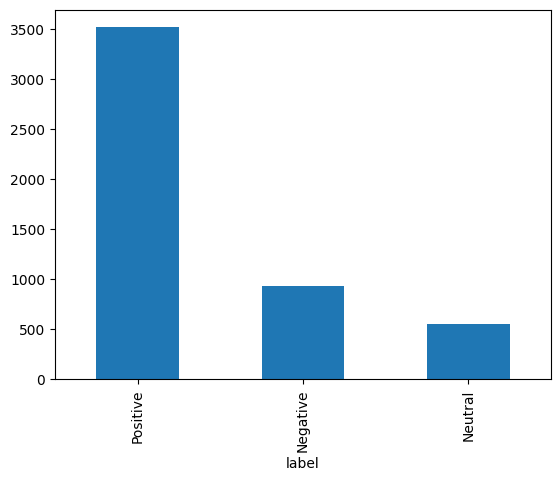

In [ ]:
df['label'].value_counts().plot(kind='bar')
plt.show()

####**Text Preprocessing**

In [ ]:

# Download necessary NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Initialize Stopwords and Lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Clean and preprocess the input text by removing URLs, hashtags, punctuation,
    converting to lowercase, removing stopwords, lemmatizing, and handling negations.
    """
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
    text = re.sub(r'#(\w+)', r'\1', text)  # Remove hashtags but retain the word

    # Handle negations: flip the sentiment of words after negation
    negations = ['not', 'no', "n't", 'never', 'none', 'without', 'doesn’t', 'isn’t']
    words = text.split()
    negation_flag = False
    processed_words = []

    for word in words:
        if word in negations:
            negation_flag = True  # Flag that negation started
        elif negation_flag:
            # If negation is active, we can reverse the sentiment of the word (optional, simplistic approach)
            word = f"neg_{word}"  # Add a prefix to denote negation (simplistic example)
            negation_flag = False  # Turn off negation after one word
        processed_words.append(word)

    text = ' '.join(processed_words)
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabetic characters
    text = text.lower()  # Convert to lowercase
    words = text.split()
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    words = [lemmatizer.lemmatize(word) for word in words]  # Lemmatize each word
    return ' '.join(words)


# Preprocess text
df['cleaned_text'] = df['text'].apply(preprocess_text)

####**Feature Engineering**

**New Features**

In [ ]:
# Download the VADER lexicon
nltk.download('vader_lexicon', quiet=True)

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Apply one-liner code for length and polarity
df['review_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
df['polarity'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [ ]:
df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,label,cleaned_text,review_length,polarity
10650,rWbQ-ASuViYP07Uu9PZu4Q,gfos-L-4tZ7TKektSglXcQ,LLmN5AZ3_U2U4nm6sY6j2Q,5.0,0,0,0,Thank you for great bottle service for bday an...,2012-11-06 16:17:02,Positive,thank great bottle service bday halloween part...,17,0.9792
2041,8bGJJrY9zhMpKqIkmKNi-w,C410dZNCFbEL7D4vMRF_Qw,sr-5EY6bmp4jINhea06MjA,3.0,0,0,0,"The experience is fun and girly, but the food ...",2017-04-08 01:47:10,Neutral,experience fun girly food doesnt back go desse...,16,0.0390
8668,NsUuPB5IDxiEUWxvjrYBAg,5lu4gnEVfpNET3MSJf9TTQ,_aKr7POnacW_VizRKBpCiA,5.0,0,0,0,This deli is truly as good as it gets. From t...,2011-03-21 20:04:40,Positive,deli truly good get food staff customer blue c...,27,0.8910
1114,PfCWXddU2W8Sc5DL48vVUw,o0emAbW2Z9MnyGxBUzH2ZA,pafrjSu3h0v0N8GR3ghNtQ,4.0,1,0,1,Great staff. Nothing is ever disappointing - ...,2013-05-07 01:50:07,Positive,great staff nothing ever disappointing chili c...,22,0.9286
13902,hGdwv0BszgAo_Fg-jXUuHg,ozUHEpWDfRn7IKqluK503A,AbtYqoBGuvlWmR1gU0c3XA,4.0,0,0,0,My friend lives across the street from here so...,2012-07-16 17:02:57,Positive,friend life across street always find stopping...,44,0.8171


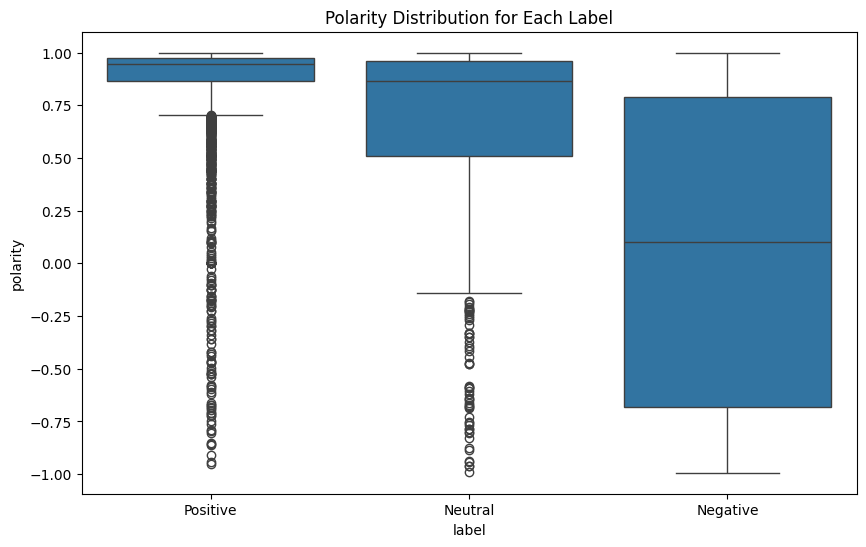

In [ ]:
# Assuming you have 'label' column (Positive, Negative, Neutral) and 'polarity' column
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='polarity', data=df)
plt.title('Polarity Distribution for Each Label')
plt.show()

**Train and Test Split**

In [ ]:
X = df['cleaned_text']
y = df['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

**TF_IDF Vectorizer**

In [ ]:
# TF-IDF Vectorizer for Unigram+Bigram
vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', max_features = 5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

**Label Encoding**

In [ ]:
# Label Encoding for multi-class target variable
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

**Class Imbalance - SMOTE Technique**

In [ ]:
# Handle Class Imbalance using SMOTE (Synthetic Minority Over-sampling Technique)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vec, y_train_encoded)

####**Model Training and Evaluation**

**Model Training**

In [ ]:
start_time = time.time()
# Initialize the baseline SVC model
svc = SVC(kernel ='linear', random_state=42)
# Train the model
svc.fit(X_train_resampled, y_train_resampled)

end_time = time.time()

train_time = end_time - start_time
print(f"Training Time: {train_time} seconds")

Training Time: 21.7638418674469 seconds


**Training Data Evaluation**

In [ ]:
# Initialize the baseline SVC model
svc = SVC(kernel ='linear', random_state=42)

# Train the model
svc.fit(X_train_resampled, y_train_resampled)

# Predict on training data
y_train_pred = svc.predict(X_train_resampled)

# Evaluate on training data
print("Training Data Evaluation:\n" )
print("Confusion Matrix (Train):\n")
print(confusion_matrix(y_train_resampled, y_train_pred))
print("Classification Report (Train):\n")
print(classification_report(y_train_resampled, y_train_pred))
print("Accuracy (Train):", accuracy_score(y_train_resampled, y_train_pred))

Training Data Evaluation:

Confusion Matrix (Train):

[[2455    3    3]
 [   0 2457    4]
 [  13   27 2421]]
Classification Report (Train):

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2461
           1       0.99      1.00      0.99      2461
           2       1.00      0.98      0.99      2461

    accuracy                           0.99      7383
   macro avg       0.99      0.99      0.99      7383
weighted avg       0.99      0.99      0.99      7383

Accuracy (Train): 0.9932276852228091


**Test Data Evaluation**

Testing Data Evaluation:

Confusion Matrix (Test):

[[202  42  35]
 [ 46  49  72]
 [ 32  72 950]]
Classification Report (Test):

              precision    recall  f1-score   support

    Negative       0.72      0.72      0.72       279
     Neutral       0.30      0.29      0.30       167
    Positive       0.90      0.90      0.90      1054

    accuracy                           0.80      1500
   macro avg       0.64      0.64      0.64      1500
weighted avg       0.80      0.80      0.80      1500

Accuracy (Test): 0.8006666666666666


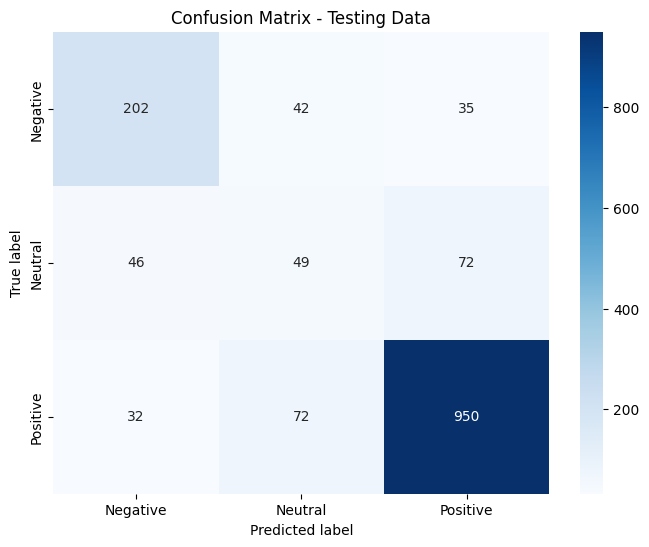

In [ ]:
# Predict on test data
y_test_pred = svc.predict(X_test_vec)

# Convert predicted numeric labels back to original string labels
y_test_pred_labels = label_encoder.inverse_transform(y_test_pred)

# Evaluate on testing data using original string labels for both y_test and y_test_pred_labels
print("Testing Data Evaluation:\n")
print("Confusion Matrix (Test):\n")
print(confusion_matrix(y_test, y_test_pred_labels))
print("Classification Report (Test):\n")
print(classification_report(y_test, y_test_pred_labels))
print("Accuracy (Test):", accuracy_score(y_test, y_test_pred_labels))

# Plot confusion matrix for testing data
plt.figure(figsize=(8, 6))
conf_matrix_test = confusion_matrix(y_test, y_test_pred_labels)
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Testing Data")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

####**Feature Importance**

In [ ]:
feature_importance = svc.coef_.toarray().flatten()  # Convert to dense array before flattening

feature_importance = feature_importance[:len(feature_names)]
feature_names = vectorizer.get_feature_names_out()
importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': feature_importance})
importance_df = importance_df.sort_values(by='Coefficient', ascending=False)
print(importance_df.head(10)) # Print the top 10 features

            Feature  Coefficient
4611         trivia     1.824247
982        customer     1.749706
1171  disappointing     1.687493
475        broccoli     1.653605
2909   negvery good     1.653283
2082       horrible     1.637791
4940          worst     1.535757
3621        refused     1.521325
41         adjacent     1.512289
2825          negbe     1.501006


####**Cross Validation**

In [ ]:
cv_scores = cross_val_score(svc, X_train_resampled, y_train_resampled, cv=3, scoring ='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean()}")

Cross-validation scores: [0.93376676 0.95530272 0.95245835]
Mean CV score: 0.9471759447379114


- The cross-validation results show that your model performs consistently well with accuracy scores of 93.38%, 95.53%, and 95.25% across three folds. The mean cross-validation score is 94.72%, indicating strong overall performance. This suggests that the model is generalizing effectively and is likely to perform well on unseen data.

####**Next Steps**

- Hyperparameter Tuning: Use GridSearchCV or RandomizedSearchCV to optimize model hyperparameters.
- Use Deep Learning: If performance plateaus, moving to deep learning techniques like BERT for text classification could yield significant improvements.